In [1]:
! pip install networkx[default] matplotlib ipympl

In [2]:
%matplotlib widget

In [ ]:
from matplotlib import pyplot
import networkx
import random
from typing import Iterator

In [4]:
ROWS = 5
COLS = 5
VERTICES_NUMBER = ROWS * COLS
NUMBER_OF_EDGES_TO_REMOVE = 15
SEED = 144

START_VERTEX = 0
FINISH_VERTEX = 20


In [5]:
class AdjacencyListGraph:
    def __init__(self, vertices_number: int):
        self.vertices: list[set[int]] = [set() for _ in range(vertices_number)]

    def get_vertices_number(self) -> int:
        return len(self.vertices)

    def set_relation(self, x: int, y: int):
        self.vertices[x].add(y)

    def remove_relation(self, x: int, y: int):
        self.vertices[x].discard(y)

    def has_relation(self, x: int, y: int):
        return y in self.vertices[x]

    def is_connected(self):
        visited = [False] * len(self.vertices)

        def dfs(vertex_number: int):
            visited[vertex_number] = True
            for neighbour_number in self.vertices[vertex_number]:
                if not visited[neighbour_number]:
                    dfs(neighbour_number)

        dfs(0)
        return all(visited)

    def copy(self):
        graph = AdjacencyListGraph(len(self.vertices))
        for node_index, neighbours in enumerate(self.vertices):
            for neighbour in neighbours:
                graph.set_relation(node_index, neighbour)
        return graph

    def get_neighbours(self, vertex: int):
        return set([*self.vertices[vertex]])

    def edge_list_iterator(self) -> Iterator[tuple[int, int]]:
        for vertex_index, neighbours in enumerate(self.vertices):
            for neighbour in neighbours:
                yield (vertex_index, neighbour)
    
    def contains_vertex(self, vertex: int) -> bool:
        return vertex < self.get_vertices_number() and self.vertices[vertex] is not None

In [6]:
def create_grid_graph(rows: int, cols: int) -> AdjacencyListGraph:
    graph = AdjacencyListGraph(VERTICES_NUMBER)
    for i in range(rows):
        for j in range(cols):
            if j + 1 < cols:
                graph.set_relation(i * cols + j, i * cols + j + 1)
                graph.set_relation(i * cols + j + 1, i * cols + j)
            if i + 1 < rows:
                graph.set_relation(i * cols + j, (i + 1) * cols + j)
                graph.set_relation((i + 1) * cols + j, i * cols + j)
    return graph

In [7]:
def delete_graph_edges(
    graph: AdjacencyListGraph, edges_number: int
) -> AdjacencyListGraph:
    processed_graph = graph.copy()
    relations = tuple(processed_graph.edge_list_iterator())
    i = 0
    while i < edges_number:
        vertex1, vertex2 = random.choice(relations)
        if not processed_graph.has_relation(vertex1, vertex2):
            continue
        processed_graph.remove_relation(vertex1, vertex2)
        processed_graph.remove_relation(vertex2, vertex1)
        if not processed_graph.is_connected():
            processed_graph.set_relation(vertex1, vertex2)
            processed_graph.set_relation(vertex2, vertex1)
            continue
        i += 1
    return processed_graph

In [8]:
def get_searching_path(graph: AdjacencyListGraph, start: int, finish: int) -> list[int]:
    if not graph.contains_vertex(start) or not graph.contains_vertex(finish):
        return []
    if not graph.is_connected():
        return []

    visited = [False] * graph.get_vertices_number()

    def dfs(vertex: int, path: list[int]):
        visited[vertex] = True
        path.append(vertex)
        if vertex == finish:
            return path
        for neighbour in graph.get_neighbours(vertex):
            if not visited[neighbour]:
                dfs(neighbour, path)
                if path[-1] == finish:
                    break
                path.append(vertex)
        return path

    return dfs(start, [])

In [11]:
def visualize_path(graph: AdjacencyListGraph, path: list[int], rows: int, cols: int):
    position = {i: (i % cols, rows - 1 - (i // cols)) for i in range(graph.get_vertices_number())}
    display_graph = networkx.Graph()
    display_graph.add_nodes_from(range(graph.get_vertices_number()))
    display_graph.add_edges_from(graph.edge_list_iterator())

    _, ax = pyplot.subplots(figsize=(6, 6))
    for i, current_vertex in enumerate(path):
        ax.clear()
        node_colors = ["lightgray"] * graph.get_vertices_number()

        for visited in path[:i + 1]:
            node_colors[visited] = "orange"

        node_colors[current_vertex] = "red" if i != len(path) - 1 else "green"

        networkx.draw(
            display_graph,
            pos=position,
            with_labels=True,
            node_color=node_colors,
            ax=ax
        )
        ax.set_title(f"Step {i + 1} - visiting vertex {current_vertex}")
        pyplot.pause(0.5)

    pyplot.show()

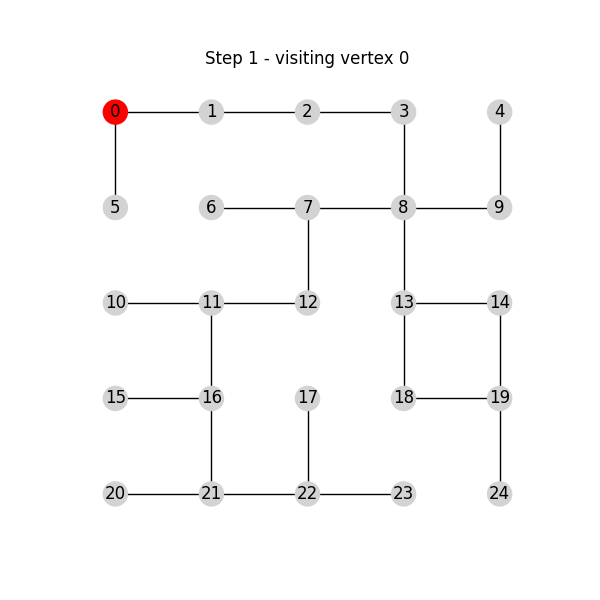

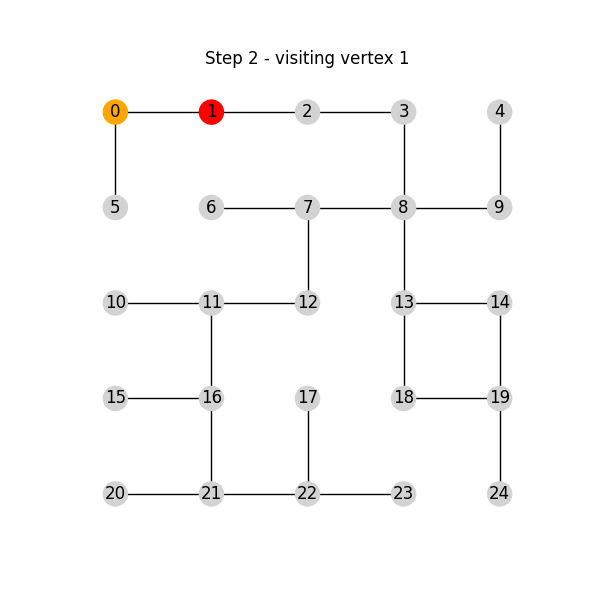

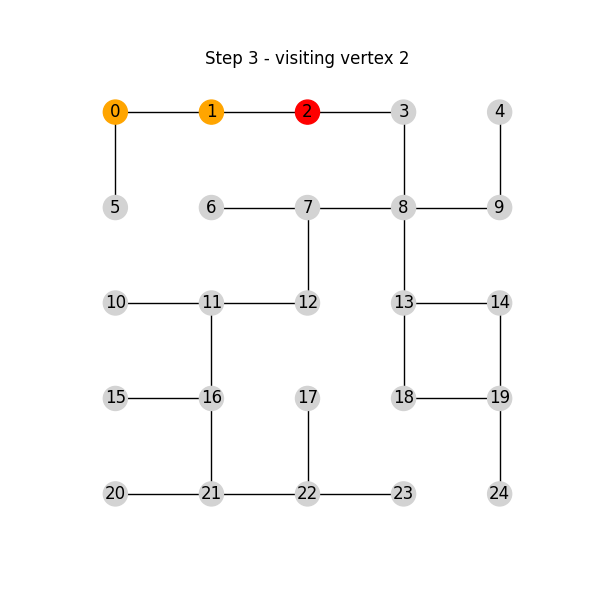

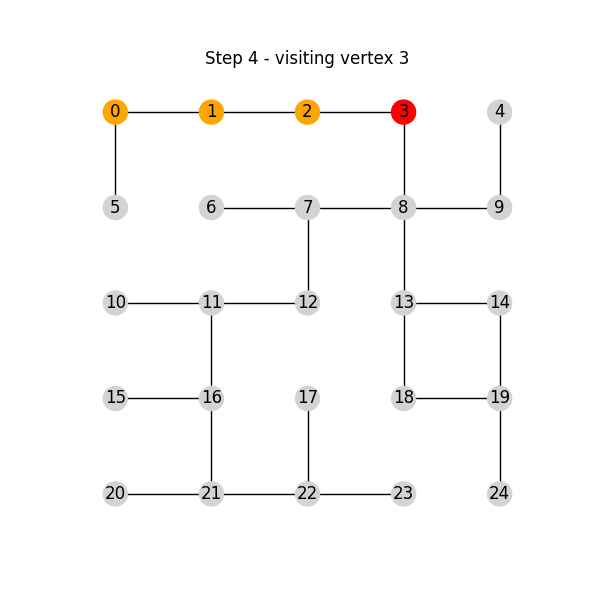

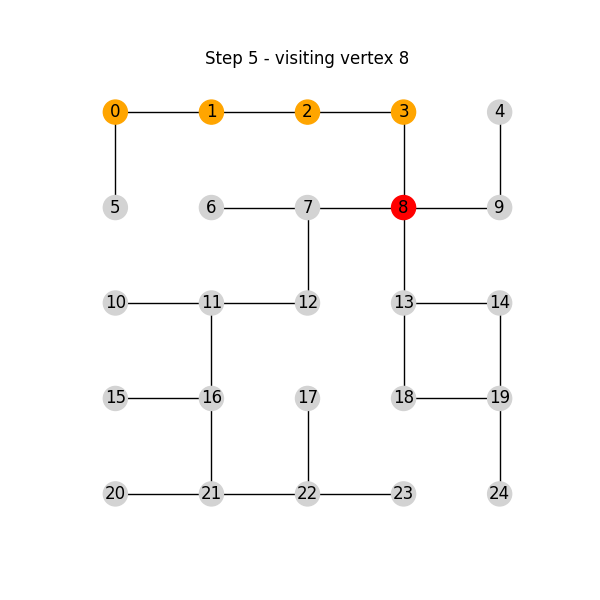

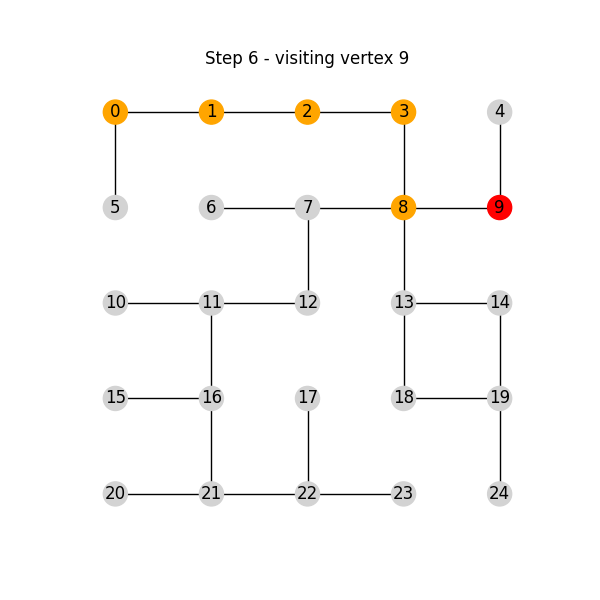

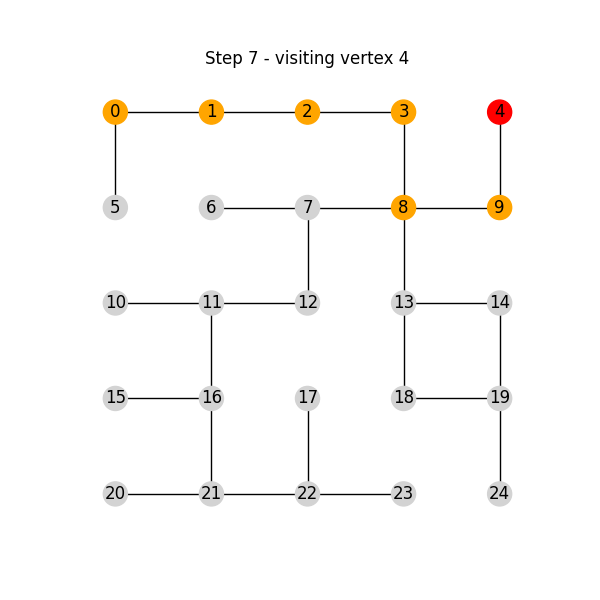

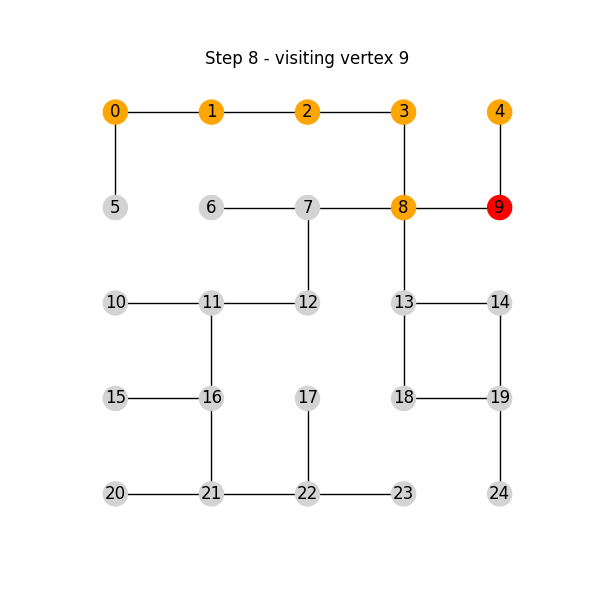

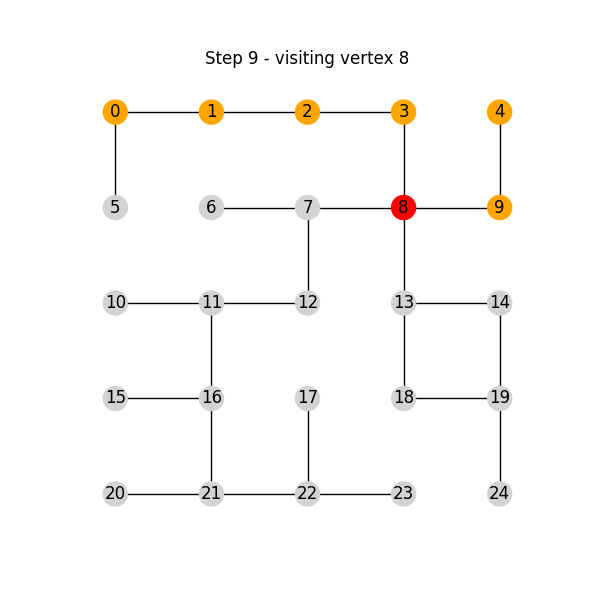

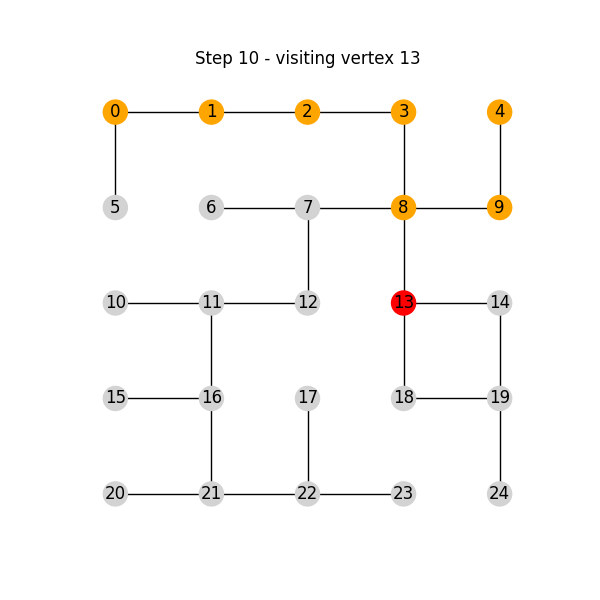

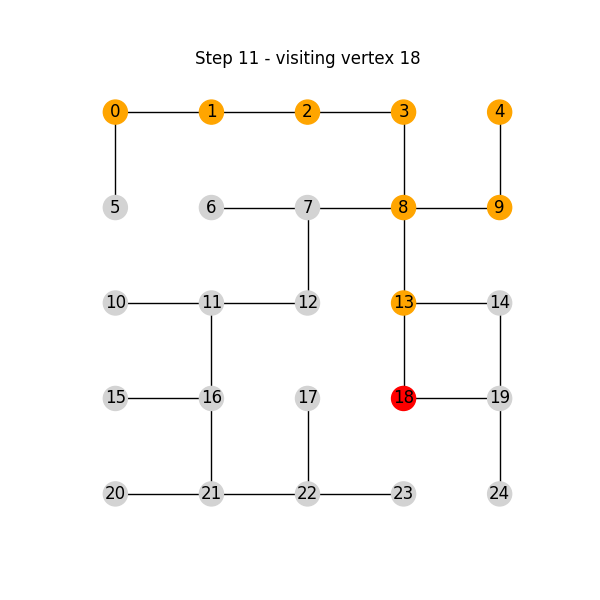

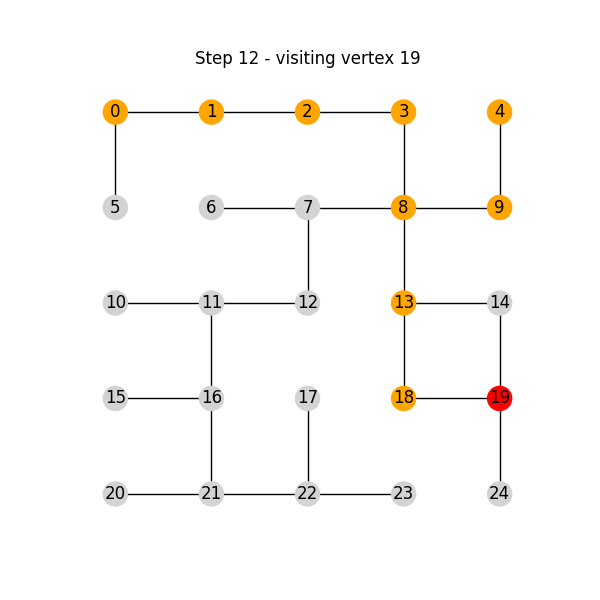

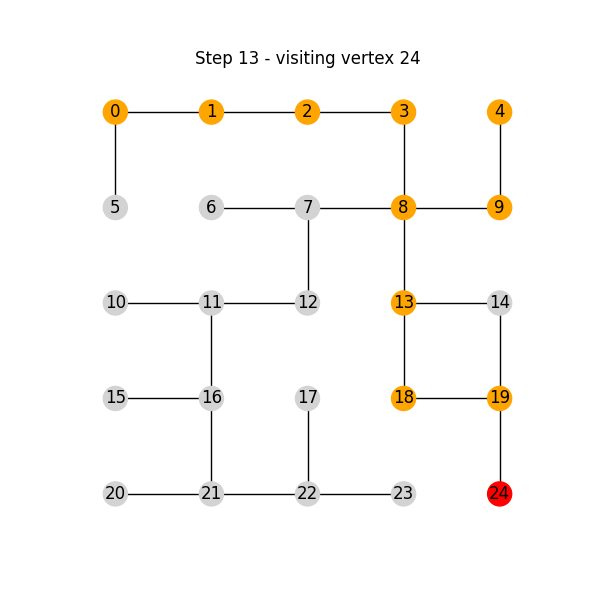

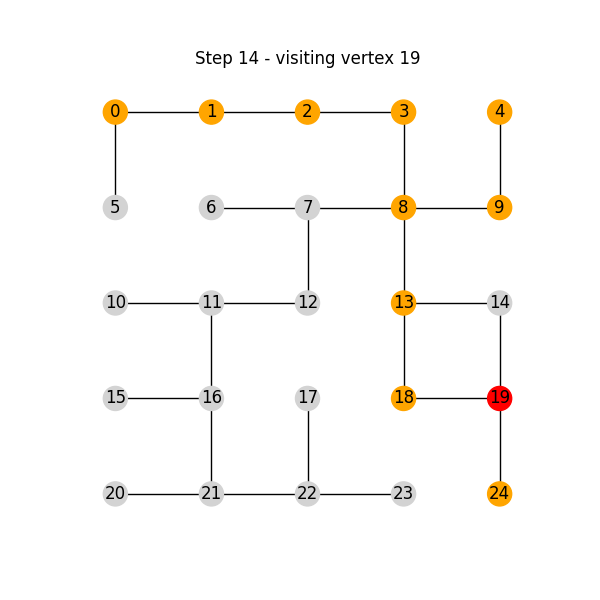

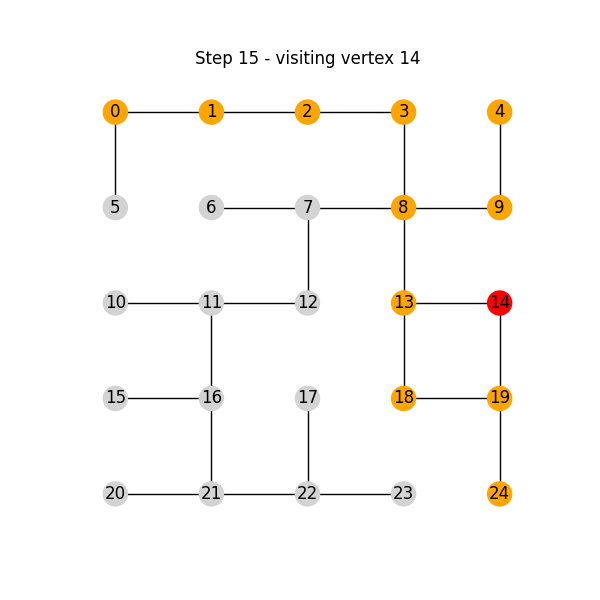

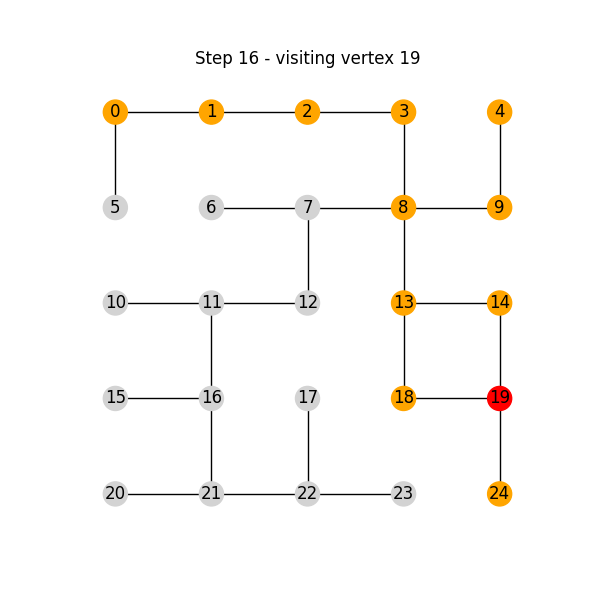

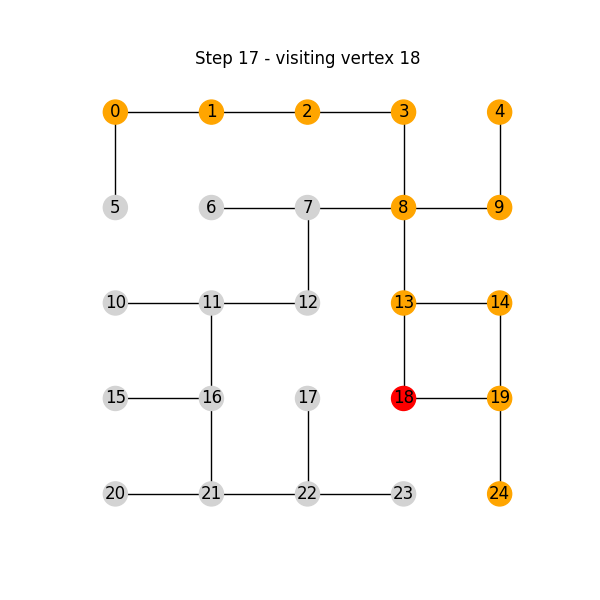

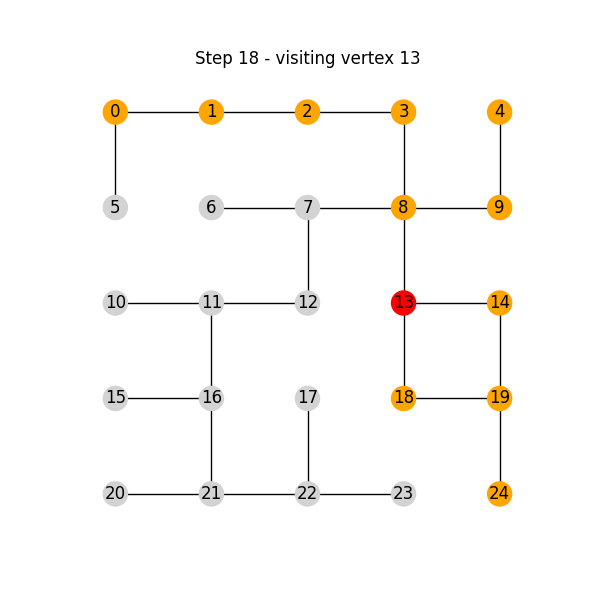

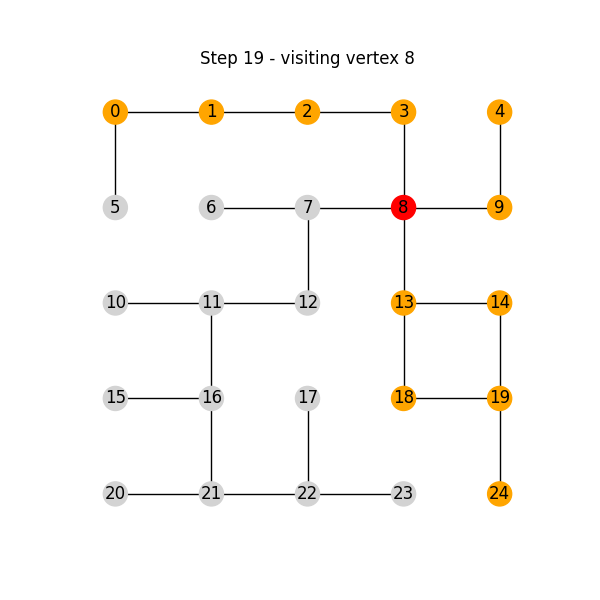

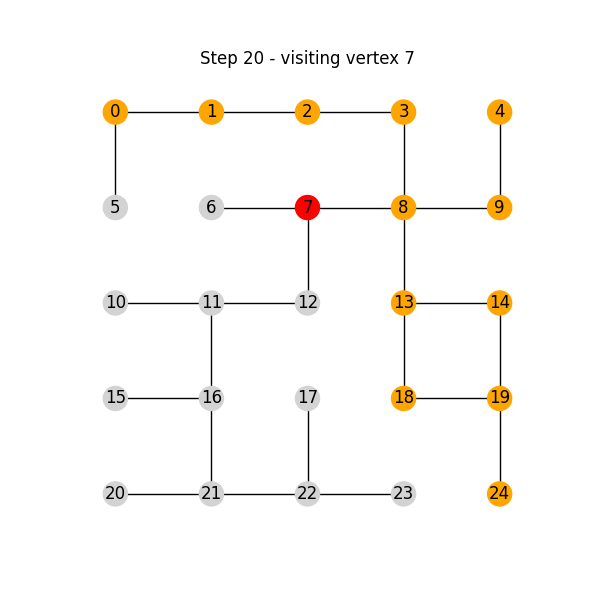

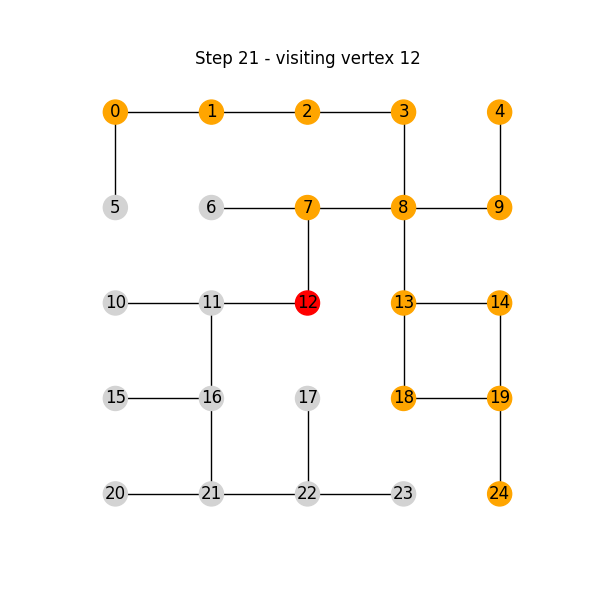

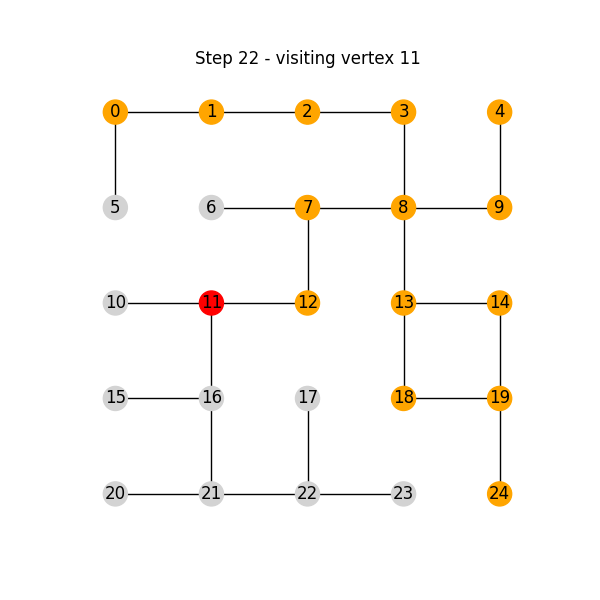

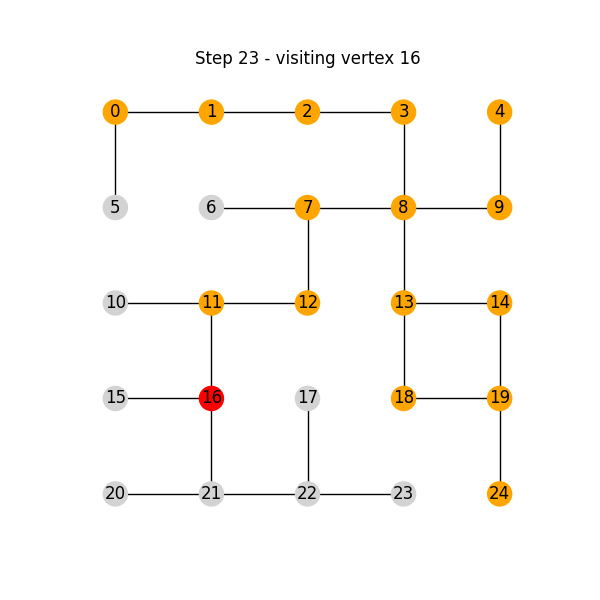

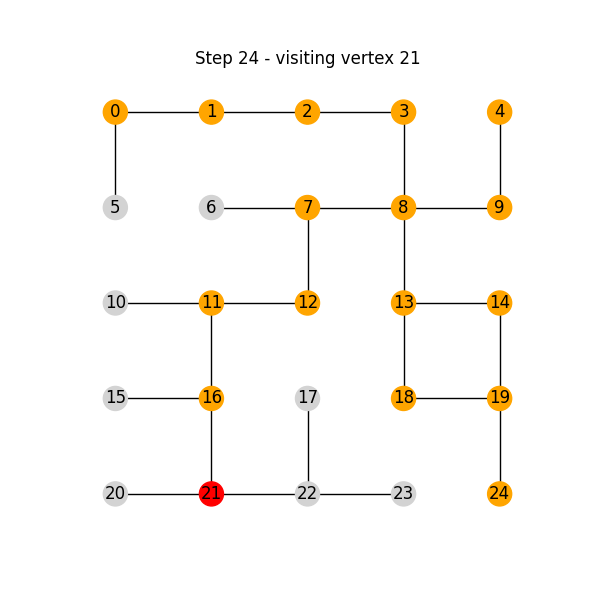

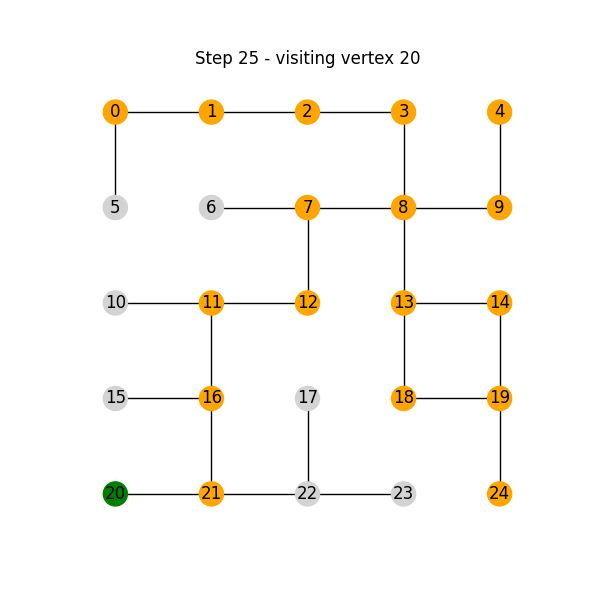

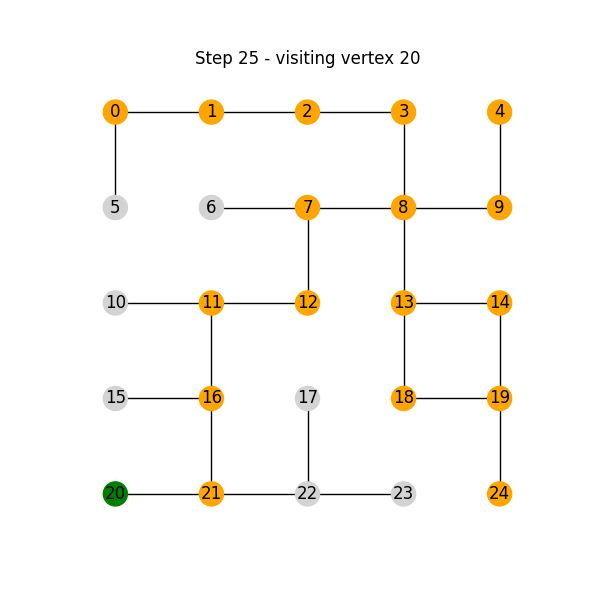

In [12]:
def main():
    random.seed(SEED)

    graph = create_grid_graph(ROWS, COLS)
    processed_graph = delete_graph_edges(graph, NUMBER_OF_EDGES_TO_REMOVE)

    searching_path = get_searching_path(processed_graph, START_VERTEX, FINISH_VERTEX)
    visualize_path(processed_graph, searching_path, ROWS, COLS)

if __name__ == "__main__":
    main()